In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import train_test_split


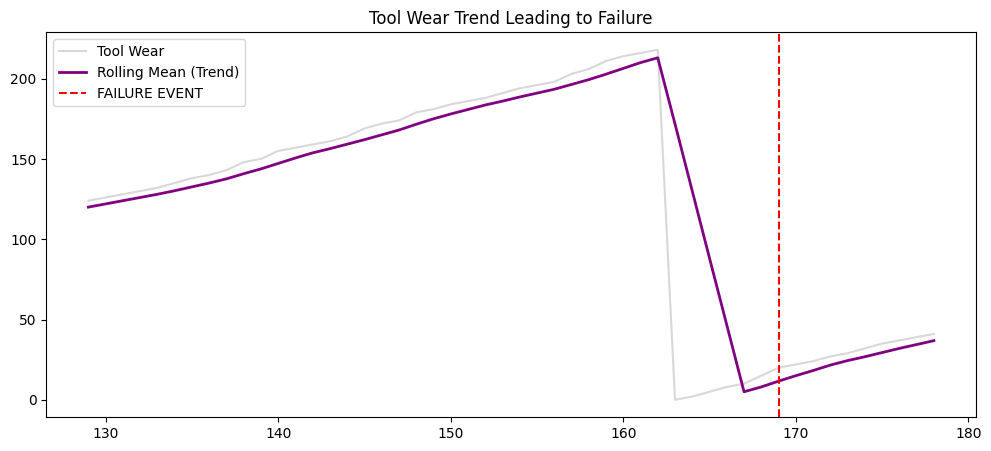

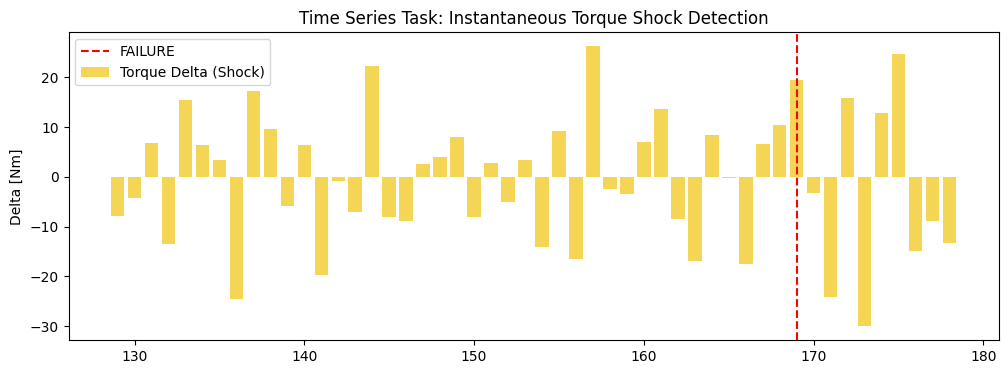

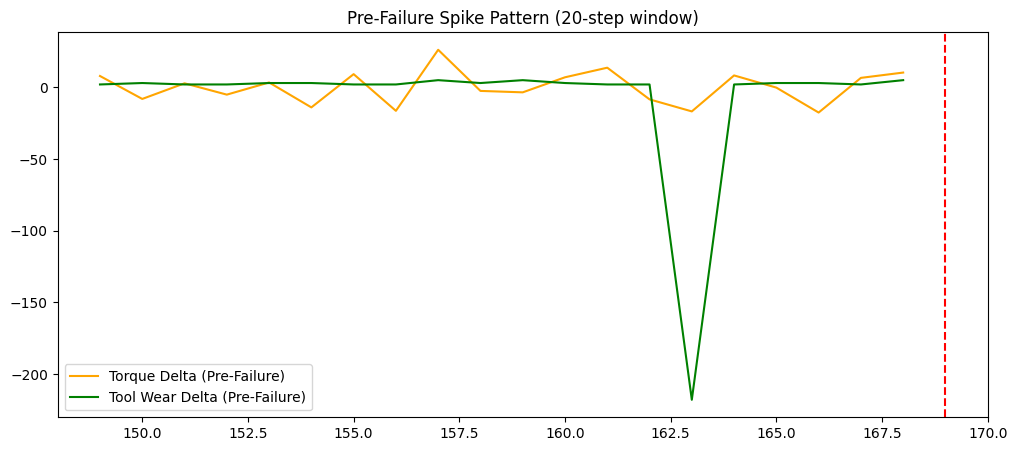


--- TIME SERIES MODEL COMPARISON ---
               Approach  F1-Score (Macro)
0      Raw Sensors Only          0.792084
1  Time Series Features          0.796436


In [11]:
# -----------------------------
# Read dataset
# -----------------------------
df = pd.read_csv("../data/cleaned_data/clustered_data.csv")

# -----------------------------
# 0. Time ordering (NO leakage)
# -----------------------------
df = df.sort_values("udi").reset_index(drop=True)

# Instead of global dropna (better practice: keep timeline intact)
df = df.iloc[5:].reset_index(drop=True)

# -----------------------------
# 1. Select failure event safely
# -----------------------------
failure_indices = df.index[df['machine_failure'] == 1].tolist()

if len(failure_indices) <= 5:
    target_idx = failure_indices[0]
else:
    target_idx = failure_indices[5]

start_idx = max(0, target_idx - 40)
end_idx = min(len(df), target_idx + 10)

ts_sample = df.iloc[start_idx:end_idx]

# -----------------------------
# 2. VISUALIZATION (PROMPT REQUIREMENTS)
# -----------------------------

# (1) Tool wear divergence (failed vs non-failed window comparison)
plt.figure(figsize=(12, 5))
plt.plot(ts_sample['udi'], ts_sample['tool_wear'],
         label='Tool Wear', color='gray', alpha=0.3)

plt.plot(ts_sample['udi'], ts_sample['tool_wear_roll_mean_5'],
         label='Rolling Mean (Trend)', color='purple', linewidth=2)

plt.axvline(x=df.loc[target_idx, 'udi'],
            color='red', linestyle='--', label='FAILURE EVENT')

plt.title('Tool Wear Trend Leading to Failure')
plt.legend()
plt.show()

# This adds the "Yellow Bars" you requested to highlight mechanical shocks
plt.figure(figsize=(12, 4))
plt.bar(ts_sample['udi'], ts_sample['torque_delta'], color='#f1c40f', alpha=0.7, label='Torque Delta (Shock)')
plt.axvline(x=df.loc[target_idx, 'udi'], color='red', linestyle='--', label='FAILURE')
plt.title('Time Series Task: Instantaneous Torque Shock Detection')
plt.ylabel('Delta [Nm]')
plt.legend()
plt.show()

# (3) Torque instability BEFORE failure (N=20 requirement)
pre_window = df.iloc[max(0, target_idx - 20):target_idx]

plt.figure(figsize=(12, 5))
plt.plot(pre_window['udi'],
         pre_window['torque_delta'],
         label='Torque Delta (Pre-Failure)',
         color='orange')

plt.plot(pre_window['udi'],
         pre_window['tool_wear_delta'],
         label='Tool Wear Delta (Pre-Failure)',
         color='green')

plt.axvline(x=df.loc[target_idx, 'udi'],
            color='red', linestyle='--')

plt.title('Pre-Failure Spike Pattern (20-step window)')
plt.legend()
plt.show()

# -----------------------------
# NOTE (required by prompt)
# -----------------------------
"""
Time series analysis here is primarily a feature engineering step.
Rolling mean, rolling std, delta, and lag features are used to
convert temporal patterns into supervised learning inputs for XGBoost.
"""

# -----------------------------
# 3. Feature Selection
# -----------------------------
y = df['machine_failure']

raw_features = [
    'air_temperature',
    'process_temperature',
    'rotational_speed',
    'torque',
    'tool_wear'
]

ts_features = [
    col for col in df.columns
    if ('_roll_' in col or '_delta' in col or '_lag' in col)
]

# Safety check (VERY IMPORTANT for debugging)
assert len(ts_features) > 0, "ts_features is empty! Check column names."

# -----------------------------
# 4. TIME SERIES SPLIT (correct approach)
# -----------------------------
split_idx = int(len(df) * 0.8)

X_raw_train = df.iloc[:split_idx][raw_features]
X_raw_test  = df.iloc[split_idx:][raw_features]

X_ts_train  = df.iloc[:split_idx][ts_features]
X_ts_test   = df.iloc[split_idx:][ts_features]

y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

# -----------------------------
# 5. TRAIN MODELS
# -----------------------------
model_raw = XGBClassifier(scale_pos_weight=25, eval_metric='logloss', random_state=42)
model_ts  = XGBClassifier(scale_pos_weight=25, eval_metric='logloss', random_state=42)

model_raw.fit(X_raw_train, y_train)
model_ts.fit(X_ts_train, y_train)

# -----------------------------
# 6. PREDICTIONS + EVALUATION
# -----------------------------
pred_raw = model_raw.predict(X_raw_test)
pred_ts  = model_ts.predict(X_ts_test)

score_raw = f1_score(y_test, pred_raw, average='macro')
score_ts  = f1_score(y_test, pred_ts, average='macro')

# -----------------------------
# 7. FINAL COMPARISON TABLE
# -----------------------------
results = pd.DataFrame({
    'Approach': ['Raw Sensors Only', 'Time Series Features'],
    'F1-Score (Macro)': [score_raw, score_ts]
})

print("\n--- TIME SERIES MODEL COMPARISON ---")
print(results)